# imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [3]:
csv_path = Path(r"C:\Users\user\Desktop\div\data\files\housing.csv")
df = pd.read_csv(csv_path)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY


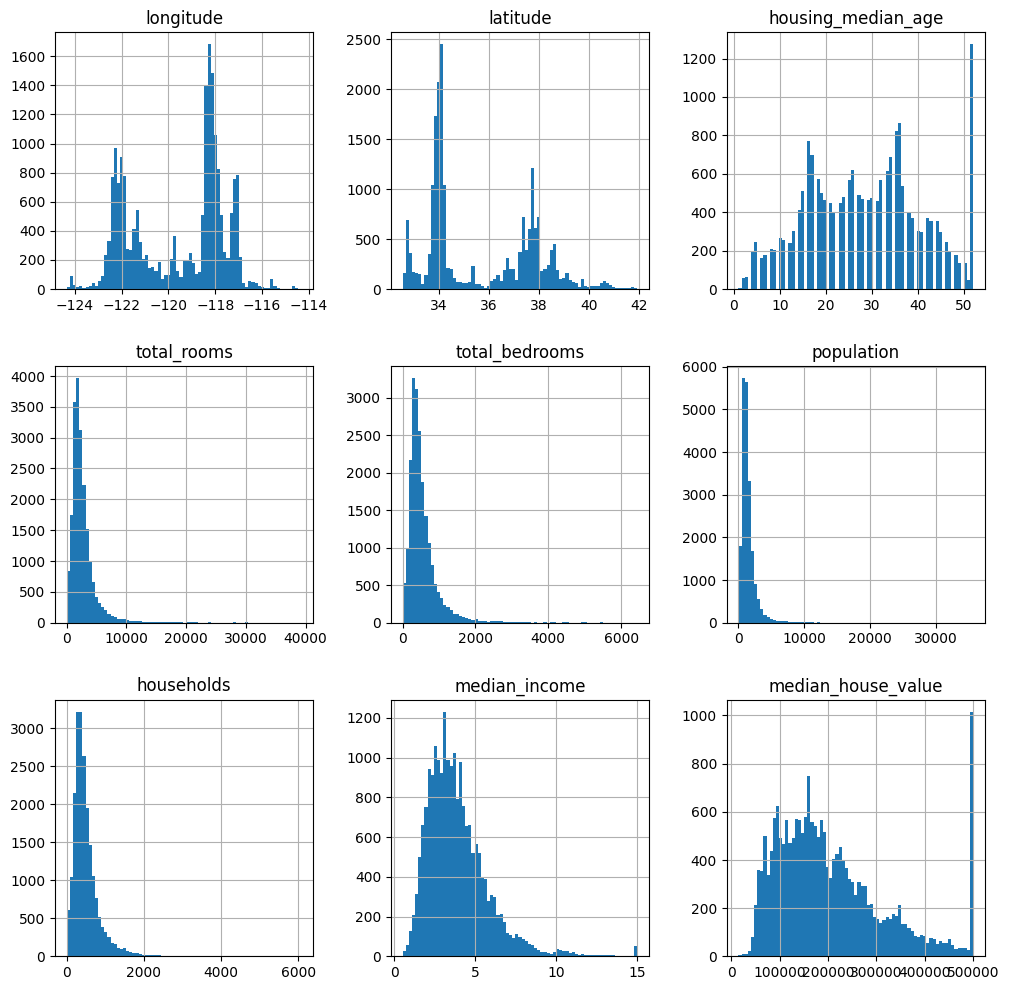

In [4]:
df.select_dtypes(include=['number']).hist(bins=75, figsize=(12, 12))
plt.show()

# outliers

### quartiles+iqr

In [6]:
# def find_outliers_with_median(series):
#     q1,q3 = series.quantile([0.25, 0.75])
#     iqr = np.abs(q3 - q1)

#     lower_bound = q1 - 1.5 * iqr
#     upper_bound = q3 + 1.5 * iqr

#     outlier_mask = (series < lower_bound) | (series > upper_bound)
#     return outlier_mask

# def find_outliers_with_mean(series, threshold=3):
#     mean = series.mean()
#     std = series.std()

#     lower_bound = mean - threshold * std
#     upper_bound = mean + threshold * std

#     outlier_mask = (series < lower_bound) | (series > upper_bound)
#     return outlier_mask

# outliers1 = find_outliers_with_median(df['median_house_value'])
# outliers2 = find_outliers_with_mean(df['housing_median_age'], threshold=1.8)
# outliers = outliers1 | outliers2

# fig, axs = plt.subplots(1, 2, figsize=(12, 4))
# axs[0].hist(df.loc[~outliers1, 'median_house_value'], bins=100, color='blue')
# axs[0].hist(df.loc[outliers1, 'median_house_value'], bins=3, color='red')
# axs[1].hist(df.loc[~outliers2, 'housing_median_age'], bins=100, color='blue')
# axs[1].hist(df.loc[outliers2, 'housing_median_age'], bins=100, color='red')
# axs[0].set_title('median_house_value')
# axs[1].set_title('housing_median_age')
# plt.show()

### simple

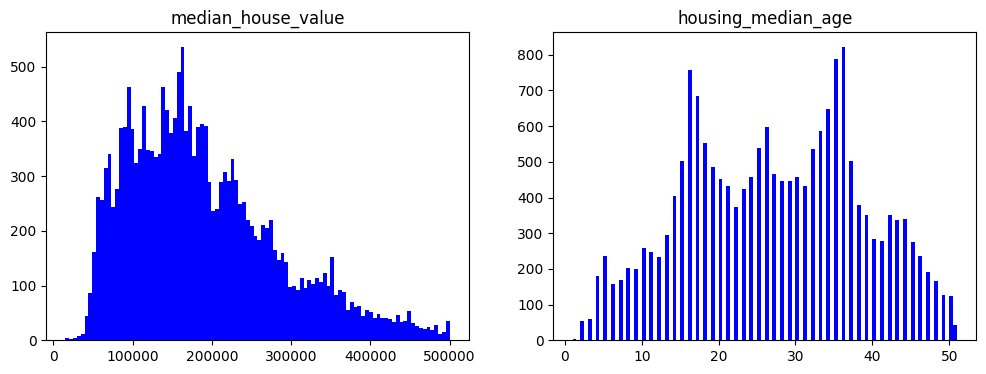

In [7]:
outliers1 = df['median_house_value'] == df['median_house_value'].max()
outliers2 = df['housing_median_age'] == df['housing_median_age'].max()
outliers = outliers1 | outliers2

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].hist(df.loc[~outliers, 'median_house_value'], bins=100, color='blue')
axs[1].hist(df.loc[~outliers, 'housing_median_age'], bins=100, color='blue')
axs[0].set_title('median_house_value')
axs[1].set_title('housing_median_age')
plt.show()


In [8]:
df = df.loc[~outliers, :].copy()
print(df.shape)
df.head(3)

(18572, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


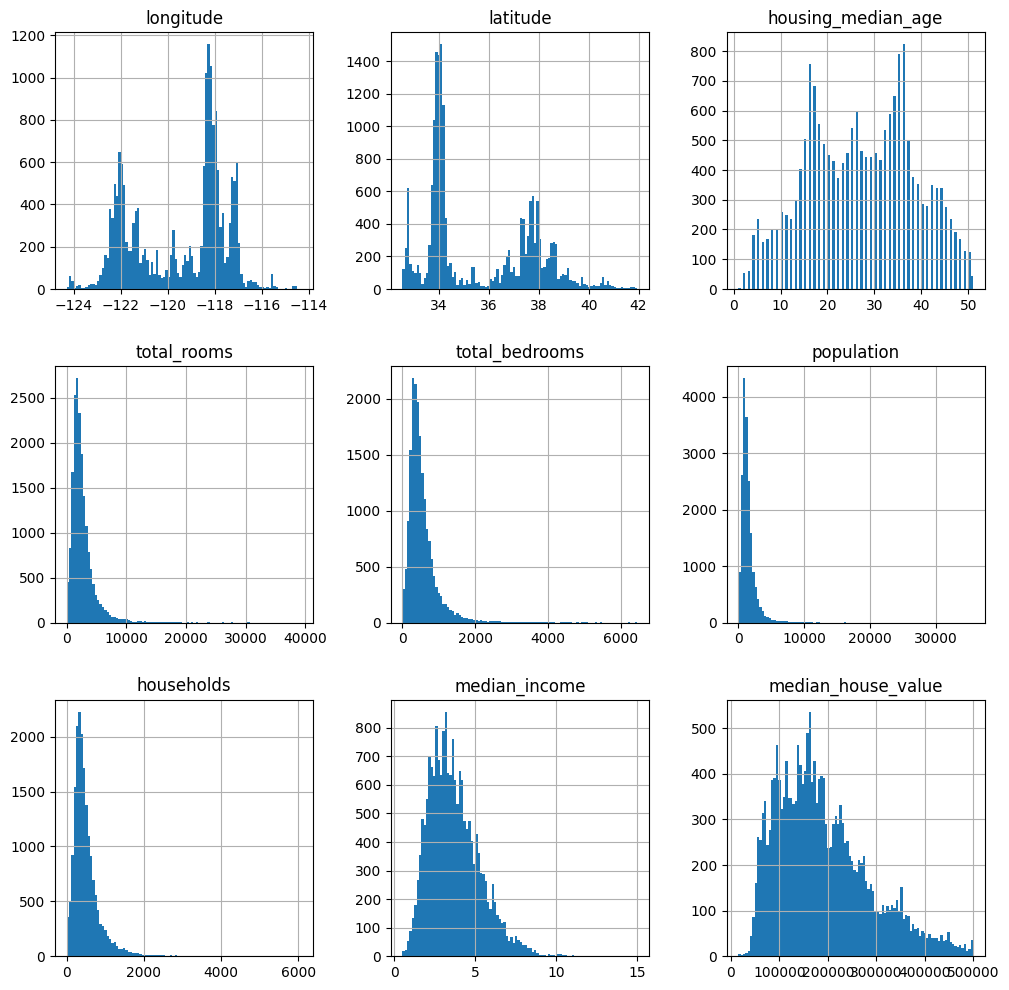

In [9]:
df.select_dtypes(include=['number']).hist(bins=100, figsize=(12, 12))
plt.show()

# split

In [29]:
y = df.drop('ocean_proximity', axis=1)['median_house_value']
X = df.drop('ocean_proximity', axis=1).drop('median_house_value', axis=1)

X.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [32]:
X_train.shape, y_train.shape
# X_test.shape, y_test.shape

((12443, 8), (12443,))

In [42]:
# from sklearn.impute import SimpleImputer

# simp_imp = SimpleImputer(strategy = 'median')
# simp_imp.fit(X_train)
# Z = simp_imp.transform(X_train)
# Z = pd.DataFrame(Z)
# Z.shape

In [43]:
# from sklearn.preprocessing import StandardScaler

# ss = StandardScaler()
# ss.fit(Z)
# pd.DataFrame(ss.transform(Z))

In [ ]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
	('imp', SimpleImputer(strategy='mean')),
	('scaler', StandardScaler()), 
])

log_pipeline = Pipeline([
	('imp', SimpleImputer(strategy='median')), 
	# ('log', FunctionTransformer(func=np.log, inverse_func=np.exp)),
	('log', FunctionTransformer(func=np.log1p, inverse_func=np.expm1, feature_names_out='one-to-one')),
	('scaler', StandardScaler())
])

num_cols = ['longitude', 'latitude', 'housing_median_age']
log_cols = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

from sklearn.compose import ColumnTransformer

tr = ColumnTransformer([
	('LOG', log_pipeline, log_cols),
	('NUM', num_pipeline, num_cols)
])

X_train_transformed = tr.fit_transform(X_train)
pd.DataFrame(X_train_transformed, columns=tr.get_feature_names_out())

,LOG__total_rooms,LOG__total_bedrooms,LOG__population,LOG__households,LOG__median_income,NUM__longitude,NUM__latitude,NUM__housing_median_age
0,0.366078,0.125686,0.579527,0.292121,0.503305,0.789366,-0.691361,0.701799
1,0.237408,0.166543,-0.071284,0.402501,1.170608,0.870135,-0.905262,-1.580952
2,-0.120238,-0.202677,-0.083781,-0.206947,-0.817628,0.097782,-0.040357,0.614001
3,0.417306,0.160778,0.025982,0.181451,1.325741,0.839847,-0.895962,-0.615172
4,0.656524,0.440378,0.245345,0.448351,0.813694,0.784318,-0.886662,0.087212
...,...,...,...,...,...,...,...,...
12438,-0.401402,0.083617,-0.579707,0.175378,-1.084927,-1.219761,0.964050,-2.107740
12439,-0.233399,-0.236670,0.193935,-0.148276,0.404904,0.774222,-0.770411,0.526203
12440,0.027618,-0.033975,-0.076269,0.031298,0.492889,0.718693,-0.691361,0.262809
12441,0.346046,1.060548,1.368700,1.042434,-1.490752,1.218451,-1.407466,-1.932144


In [70]:
from sklearn.linear_model import LinearRegression

reg_pipeline = Pipeline([
	('temizleme', tr),
	('modelleme', LinearRegression())
])
reg_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('temizleme', ...), ('modelleme', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('LOG', ...), ('NUM', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [71]:
y_pred = reg_pipeline.predict(X_test)
y_pred

array([170693.45719527, 120267.24662501, 346163.98113293, ...,
       179846.13745071, 304936.65493123, 218442.70261369], shape=(6129,))

In [72]:
y_test.to_numpy()

array([127500., 131600., 423900., ..., 204700., 286900., 216100.],
      shape=(6129,))

In [73]:
np.abs(y_pred - y_test.to_numpy()).mean()

np.float64(45875.69063160347)

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
	('temizleme', tr),
	('modelleme', RandomForestRegressor())
])
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_pred

array([194621., 132322., 438304., ..., 301029., 359101., 209114.],
      shape=(6129,))

In [76]:
np.abs(y_pred - y_test.to_numpy()).mean()

np.float64(28947.454129548052)